# Feature Matching and Panorama Construction

Minimal local-data comparison of SIFT and ORB

## Setup and local data

In [7]:
from pathlib import Path
import json
import random
import time

import cv2
import matplotlib

matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
cv2.setRNGSeed(SEED)

ROOT = Path.cwd()
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
PANORAMAS = RESULTS / 'panoramas'
SUMMARY = RESULTS / 'summary'
for folder in (PANORAMAS, SUMMARY):
    folder.mkdir(parents=True, exist_ok=True)

CFG = {
    'detectors': ('SIFT', 'ORB'),
    'ratio_threshold': 0.75,
    'ransac_threshold': 3.0,
    'max_matches_to_draw': 80,
    'max_canvas_pixels': 25_000_000,
}

OPENCV_SCENES = {
    'boat': [DATA / 'opencv_samples' / 'boat' / f'boat{i}.jpg' for i in range(1, 7)],
    'newspaper': [DATA / 'opencv_samples' / 'newspaper' / f'newspaper{i}.jpg' for i in range(1, 5)],
}
OXFORD_SEQUENCES = ('bark', 'boat', 'graf', 'wall', 'leuven', 'bikes')


def oxford_images(sequence):
    images = sorted((DATA / 'oxford_vgg' / sequence).glob('img*.p[pg]m'))
    if len(images) != 6:
        raise FileNotFoundError(f'Expected six Oxford images in {sequence}, found {len(images)}.')
    return images


def validate_local_data():
    missing = [path for paths in OPENCV_SCENES.values() for path in paths if not path.exists()]
    for sequence in OXFORD_SEQUENCES:
        folder = DATA / 'oxford_vgg' / sequence
        missing.extend([] if len(list(folder.glob('img*.p[pg]m'))) == 6 else [folder])
        homography = folder / 'H1to6p'
        if not homography.exists():
            missing.append(homography)
    if missing:
        listed = '\n'.join(f' - {path.relative_to(ROOT)}' for path in missing)
        raise FileNotFoundError(f'Local dataset files are missing:\n{listed}')


validate_local_data()
print('Local datasets found. No download step is required.')


Local datasets found. No download step is required.


## Matching and stitching helpers

In [8]:
def read_image(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Could not read {path}')
    return image


def resize_for_stitching(image, max_dim=600):
    height, width = image.shape[:2]
    scale = min(1.0, max_dim / max(height, width))
    return cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA) if scale < 1 else image


def detector_for(name):
    if name == 'SIFT':
        return cv2.SIFT_create(), cv2.NORM_L2
    if name == 'ORB':
        return cv2.ORB_create(nfeatures=5000), cv2.NORM_HAMMING
    raise ValueError(f'Unknown detector: {name}')


def reprojection_error(H, H_gt, image_shape):
    height, width = image_shape[:2]
    xs = np.linspace(0, width - 1, 20)
    ys = np.linspace(0, height - 1, 20)
    points = np.array([(x, y) for y in ys for x in xs], dtype=np.float32).reshape(-1, 1, 2)
    estimated = cv2.perspectiveTransform(points, H).reshape(-1, 2)
    reference = cv2.perspectiveTransform(points, H_gt).reshape(-1, 2)
    return float(np.mean(np.linalg.norm(estimated - reference, axis=1)))


def run_pair(image_a, image_b, *, dataset, scene, pair, detector, H_gt=None):
    start = time.perf_counter()
    gray_a = cv2.cvtColor(image_a, cv2.COLOR_BGR2GRAY)
    gray_b = cv2.cvtColor(image_b, cv2.COLOR_BGR2GRAY)
    extractor, norm = detector_for(detector)

    keypoints_a, descriptors_a = extractor.detectAndCompute(gray_a, None)
    keypoints_b, descriptors_b = extractor.detectAndCompute(gray_b, None)
    record = {
        'dataset': dataset, 'scene': scene, 'pair': pair, 'detector': detector,
        'keypoints_a': len(keypoints_a), 'keypoints_b': len(keypoints_b),
        'matches': 0, 'inliers': 0, 'inlier_ratio': np.nan,
        'reprojection_error_px': np.nan, 'runtime_ms': np.nan, 'status': 'failed',
    }
    if descriptors_a is None or descriptors_b is None or len(descriptors_a) < 2 or len(descriptors_b) < 2:
        record['reason'] = 'not enough descriptors'
        record['runtime_ms'] = round((time.perf_counter() - start) * 1000, 2)
        return record, None, None

    candidates = cv2.BFMatcher(norm).knnMatch(descriptors_a, descriptors_b, k=2)
    good = [first for first, second in candidates if first.distance < CFG['ratio_threshold'] * second.distance]
    record['matches'] = len(good)
    if len(good) < 4:
        record['reason'] = 'fewer than four ratio-test matches'
        record['runtime_ms'] = round((time.perf_counter() - start) * 1000, 2)
        return record, None, None

    source = np.float32([keypoints_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    target = np.float32([keypoints_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(source, target, cv2.RANSAC, CFG['ransac_threshold'])
    if H is None or mask is None:
        record['reason'] = 'RANSAC could not estimate a homography'
        record['runtime_ms'] = round((time.perf_counter() - start) * 1000, 2)
        return record, None, None

    inliers = int(mask.ravel().sum())
    record.update({
        'inliers': inliers,
        'inlier_ratio': round(inliers / len(good), 4),
        'runtime_ms': round((time.perf_counter() - start) * 1000, 2),
        'status': 'ok',
        'homography': H.tolist(),
    })
    if H_gt is not None:
        record['reprojection_error_px'] = round(reprojection_error(H, H_gt, image_a.shape), 3)
    visual_data = (keypoints_a, keypoints_b, good, mask.ravel().astype(bool))
    return record, H, visual_data


def feather_panorama(images, transforms):
    corners = []
    for image, H in zip(images, transforms):
        height, width = image.shape[:2]
        image_corners = np.float32([[0, 0], [width, 0], [width, height], [0, height]]).reshape(-1, 1, 2)
        corners.append(cv2.perspectiveTransform(image_corners, H).reshape(-1, 2))
    corners = np.vstack(corners)
    minimum = np.floor(corners.min(axis=0)).astype(int)
    maximum = np.ceil(corners.max(axis=0)).astype(int)
    width, height = (maximum - minimum).tolist()
    if width <= 0 or height <= 0 or width * height > CFG['max_canvas_pixels']:
        raise ValueError(f'unsafe panorama canvas: {width} x {height}')
    translate = np.array([[1, 0, -minimum[0]], [0, 1, -minimum[1]], [0, 0, 1]], dtype=float)

    numerator = np.zeros((height, width, 3), dtype=np.float32)
    denominator = np.zeros((height, width), dtype=np.float32)
    for image, H in zip(images, transforms):
        warped = cv2.warpPerspective(image, translate @ H, (width, height))
        mask = cv2.warpPerspective(np.full(image.shape[:2], 255, dtype=np.uint8), translate @ H, (width, height))
        weights = cv2.distanceTransform(mask, cv2.DIST_L2, 3) + 1e-3
        numerator += warped.astype(np.float32) * weights[..., None]
        denominator += weights
    panorama = numerator / np.maximum(denominator[..., None], 1e-6)
    occupied = denominator > 0
    ys, xs = np.where(occupied)
    return panorama[ys.min():ys.max() + 1, xs.min():xs.max() + 1].astype(np.uint8)


def show_bgr(image, title=''):
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()


def save_match_figure(image_a, image_b, visual_data, detector):
    keypoints_a, keypoints_b, good, inlier_mask = visual_data
    inliers = [match for match, keep in zip(good, inlier_mask) if keep][:CFG['max_matches_to_draw']]
    drawn = cv2.drawMatches(image_a, keypoints_a, image_b, keypoints_b, inliers, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    path = SUMMARY / f'imp_boat1_boat2_{detector}_inliers.png'
    cv2.imwrite(str(path), drawn)
    show_bgr(drawn, f'boat1 → boat2: {detector} RANSAC inliers')


## OpenCV panorama scenes

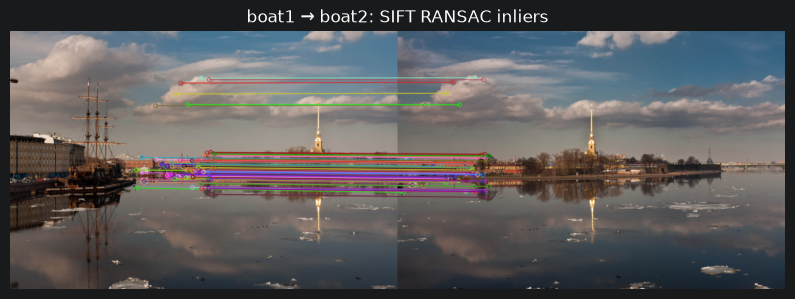

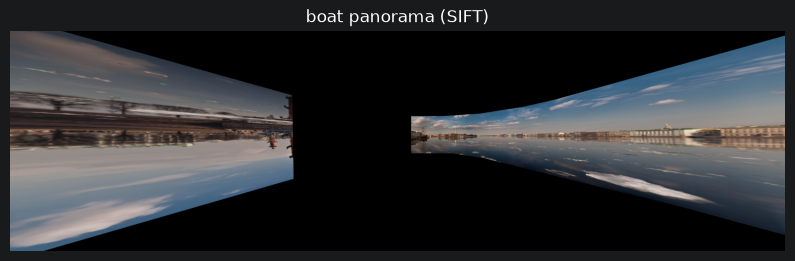

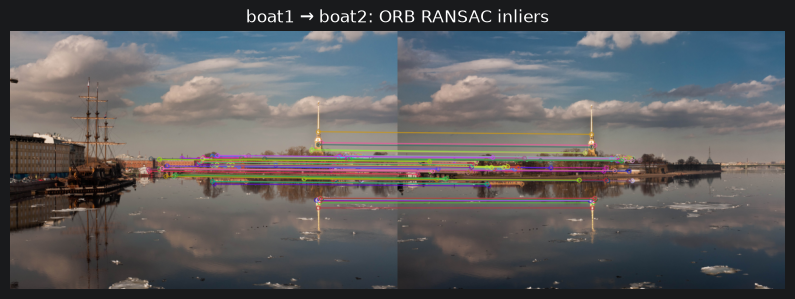

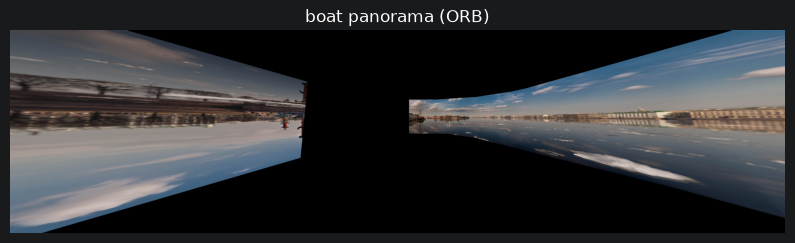

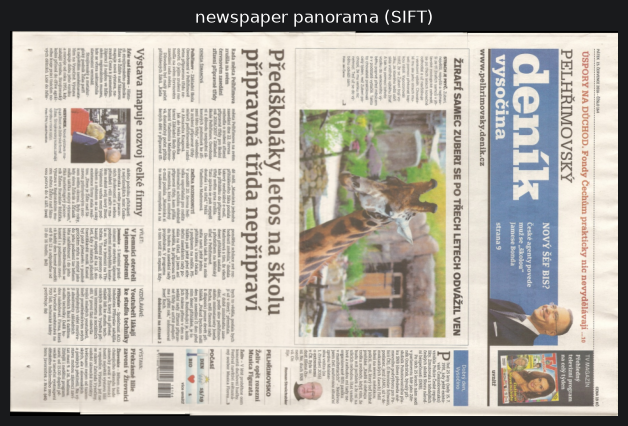

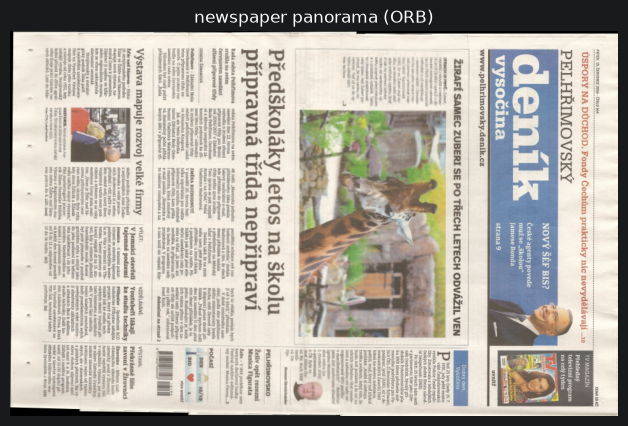

,scene,pair,detector,matches,inliers,inlier_ratio,status
0,boat,boat1.jpg → boat2.jpg,SIFT,242,229,0.9463,ok
1,boat,boat2.jpg → boat3.jpg,SIFT,209,182,0.8708,ok
2,boat,boat3.jpg → boat4.jpg,SIFT,119,103,0.8655,ok
3,boat,boat4.jpg → boat5.jpg,SIFT,180,177,0.9833,ok
4,boat,boat5.jpg → boat6.jpg,SIFT,246,209,0.8496,ok
5,boat,boat1.jpg → boat2.jpg,ORB,747,707,0.9465,ok
6,boat,boat2.jpg → boat3.jpg,ORB,843,757,0.8980,ok
7,boat,boat3.jpg → boat4.jpg,ORB,421,395,0.9382,ok
8,boat,boat4.jpg → boat5.jpg,ORB,710,670,0.9437,ok
9,boat,boat5.jpg → boat6.jpg,ORB,1047,931,0.8892,ok


In [9]:
records = []

for scene, paths in OPENCV_SCENES.items():
    images = [resize_for_stitching(read_image(path)) for path in paths]
    for detector in CFG['detectors']:
        transforms = [np.eye(3)]
        panorama_ready = True
        for index in range(len(images) - 1):
            record, H, visual_data = run_pair(
                images[index], images[index + 1], dataset='opencv_samples', scene=scene,
                pair=f'{paths[index].name} → {paths[index + 1].name}', detector=detector,
            )
            records.append(record)
            if scene == 'boat' and index == 0 and visual_data is not None:
                save_match_figure(images[index], images[index + 1], visual_data, detector)
            if H is None:
                panorama_ready = False
                break
            transforms.append(transforms[-1] @ np.linalg.inv(H))

        if panorama_ready:
            try:
                panorama = feather_panorama(images, transforms)
                output = PANORAMAS / f'imp_opencv_{scene}_{detector}.jpg'
                cv2.imwrite(str(output), panorama)
                show_bgr(panorama, f'{scene} panorama ({detector})')
            except ValueError as error:
                print(f'{scene} / {detector}: panorama skipped ({error}).')
        else:
            print(f'{scene} / {detector}: panorama skipped because a pair failed.')

opencv_table = pd.DataFrame(records)
display(opencv_table[['scene', 'pair', 'detector', 'matches', 'inliers', 'inlier_ratio', 'status']])


## Oxford robustness snapshot

In [10]:
for sequence in OXFORD_SEQUENCES:
    paths = oxford_images(sequence)
    image_a, image_b = read_image(paths[0]), read_image(paths[-1])
    H_gt = np.loadtxt(DATA / 'oxford_vgg' / sequence / 'H1to6p')
    for detector in CFG['detectors']:
        record, _, _ = run_pair(
            image_a, image_b, dataset='oxford_vgg', scene=sequence,
            pair='img1 → img6', detector=detector, H_gt=H_gt,
        )
        records.append(record)

oxford_table = pd.DataFrame(records).query("dataset == 'oxford_vgg'")
display(oxford_table[['scene', 'detector', 'matches', 'inliers', 'inlier_ratio', 'reprojection_error_px', 'status']])


,scene,detector,matches,inliers,inlier_ratio,reprojection_error_px,status
16,bark,SIFT,259,249,0.9614,1.314,ok
17,bark,ORB,27,15,0.5556,2.244,ok
18,boat,SIFT,214,149,0.6963,5.710,ok
19,boat,ORB,112,100,0.8929,5.745,ok
20,graf,SIFT,49,5,0.1020,384.207,ok
21,graf,ORB,31,5,0.1613,750.271,ok
22,wall,SIFT,27,11,0.4074,4.281,ok
23,wall,ORB,9,4,0.4444,2098.020,ok
24,leuven,SIFT,434,365,0.8410,0.281,ok
25,leuven,ORB,1113,1052,0.9452,0.366,ok


## Results

,detector,runs,mean_matches,mean_inliers,mean_runtime_ms
0,ORB,14,610.57,540.86,64.50
1,SIFT,14,506.14,451.50,146.29


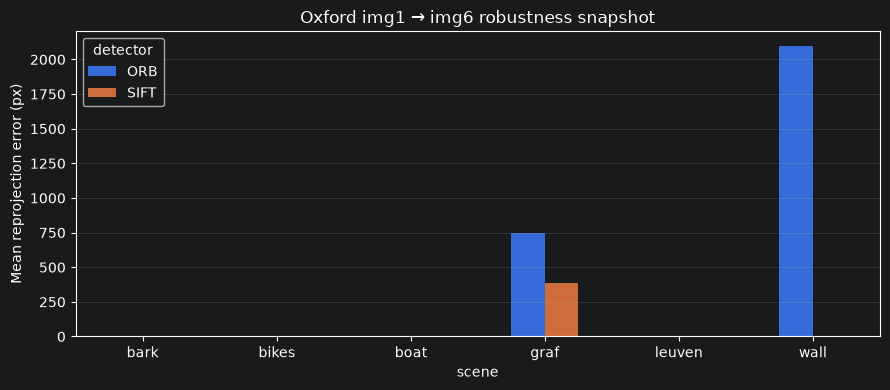

Wrote 28 comparison rows to /Users/blessziamah/Bless/msc_cv_exam_25_26/results/comparison_table.csv
Updated /Users/blessziamah/Bless/msc_cv_exam_25_26/results/metrics.json


In [11]:
table = pd.DataFrame(records)
table_for_csv = table.drop(columns=['homography'], errors='ignore')
table_for_csv.to_csv(RESULTS / 'comparison_table.csv', index=False)

with (RESULTS / 'metrics.json').open('w') as file:
    json.dump({'seed': SEED, 'config': CFG, 'n_runs': len(records), 'results': records}, file, indent=2, allow_nan=True)

summary = (table.query("status == 'ok'")
           .groupby('detector', as_index=False)
           .agg(runs=('detector', 'size'), mean_matches=('matches', 'mean'),
                mean_inliers=('inliers', 'mean'), mean_runtime_ms=('runtime_ms', 'mean')))
display(summary.round(2))

plot_data = oxford_table.pivot(index='scene', columns='detector', values='reprojection_error_px')
ax = plot_data.plot(kind='bar', figsize=(9, 4), ylabel='Mean reprojection error (px)', rot=0)
ax.set_title('Oxford img1 → img6 robustness snapshot')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
figure_path = SUMMARY / 'imp_oxford_img1_to_img6_reprojection_error.png'
plt.savefig(figure_path, dpi=160)
plt.show()
plt.close()

print(f'Wrote {len(table)} comparison rows to {RESULTS / "comparison_table.csv"}')
print(f'Updated {RESULTS / "metrics.json"}')
